# Facial Emotion Recogination

## importing libraries

In [7]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
from keras.utils import load_img

from keras.layers import Conv2D, Dense, BatchNormalization, Activation, Dropout, MaxPooling2D, Flatten
from keras.optimizers import Adam, RMSprop, SGD
from keras import regularizers
from keras.callbacks import ModelCheckpoint, CSVLogger, TensorBoard, EarlyStopping, ReduceLROnPlateau
import datetime
import matplotlib.pyplot as plt
from keras.utils import plot_model

## Importing Dataset

In [8]:
train_dir = 'facedata\\train\\'
test_dir = 'facedata\\test\\'

row, col = 48, 48
classes =4 

def count_exp(path, set_):
    dict_ = {}
    for expression in os.listdir(path):
        dir_ = path + expression
        dict_[expression] = len(os.listdir(dir_))
    df = pd.DataFrame(dict_, index=[set_])
    return df
train_count = count_exp(train_dir, 'train')
test_count = count_exp(test_dir, 'test')
print(train_count)
print(test_count)

       angry  happy  neutral   sad
train   3995   7215     4965  4830
      angry  happy  neutral   sad
test    958   1774     1233  1247


## Creating Training and test sets

In [12]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   zoom_range=0.3,
                                   horizontal_flip=True)

training_set = train_datagen.flow_from_directory(train_dir,
                                                batch_size=64,
                                                target_size=(48,48),
                                                shuffle=True,
                                                color_mode='grayscale',
                                                class_mode='categorical')

test_datagen = ImageDataGenerator(rescale=1./255)
test_set = test_datagen.flow_from_directory(test_dir,
                                                batch_size=64,
                                                target_size=(48,48),
                                                shuffle=True,
                                                color_mode='grayscale',
                                                class_mode='categorical')

Found 21005 images belonging to 4 classes.
Found 5212 images belonging to 4 classes.


In [13]:
training_set.class_indices

{'angry': 0, 'happy': 1, 'neutral': 2, 'sad': 3}

## Defining Model

In [14]:
def get_model(input_size, classes=7):
     #Initialising the CNN
    model = tf.keras.models.Sequential()   

    model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape =input_size))
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.25))

    model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Conv2D(256, kernel_size=(3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.01)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(1024, activation='relu'))
    model.add(Dropout(0.5))
    
    model.add(Dense(classes, activation='softmax'))

    #Compliling the model
    model.compile(optimizer=Adam(lr=0.0001, decay=1e-6), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

In [15]:
fernet = get_model((row,col,1), classes)
fernet.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 48, 48, 64)        18496     
                                                                 
 batch_normalization (BatchN  (None, 48, 48, 64)       256       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 24, 24, 64)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 24, 24, 64)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 24, 24, 128)       7

c:\Users\isatyamks\miniconda3\envs\tf\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [16]:
plot_model(fernet, to_file='fernet.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


### Callbacks Function

In [17]:
chk_path = 'ferNet.h5'
log_dir = "checkpoint/logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

checkpoint = ModelCheckpoint(filepath=chk_path,
                             save_best_only=True,
                             verbose=1,
                             mode='min',
                             moniter='val_loss')

earlystop = EarlyStopping(monitor='val_loss', 
                          min_delta=0, 
                          patience=3, 
                          verbose=1, 
                          restore_best_weights=True)
                        
reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.2, 
                              patience=6, 
                              verbose=1, 
                              min_delta=0.0001)


tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
csv_logger = CSVLogger('training.log')

callbacks = [checkpoint, reduce_lr, csv_logger]

## Training Model

In [18]:
steps_per_epoch = training_set.n // training_set.batch_size
validation_steps = test_set.n // test_set.batch_size

hist = fernet.fit(x=training_set,
                 validation_data=test_set,
                 epochs=60,
                 callbacks=callbacks,
                 steps_per_epoch=steps_per_epoch,
                 validation_steps=validation_steps)

Epoch 1/60
328/328 [==============================] - ETA: 0s - loss: 3.9576 - accuracy: 0.3658
Epoch 1: val_loss improved from inf to 3.88013, saving model to ferNet.h5
328/328 [==============================] - 76s 132ms/step - loss: 3.9576 - accuracy: 0.3658 - val_loss: 3.8801 - val_accuracy: 0.3465 - lr: 1.0000e-04
Epoch 2/60
328/328 [==============================] - ETA: 0s - loss: 3.2861 - accuracy: 0.4223
Epoch 2: val_loss improved from 3.88013 to 3.79481, saving model to ferNet.h5
328/328 [==============================] - 37s 114ms/step - loss: 3.2861 - accuracy: 0.4223 - val_loss: 3.7948 - val_accuracy: 0.4468 - lr: 1.0000e-04
Epoch 3/60
328/328 [==============================] - ETA: 0s - loss: 2.8473 - accuracy: 0.4548
Epoch 3: val_loss improved from 3.79481 to 2.62316, saving model to ferNet.h5
328/328 [==============================] - 23s 70ms/step - loss: 2.8473 - accuracy: 0.4548 - val_loss: 2.6232 - val_accuracy: 0.5042 - lr: 1.0000e-04
Epoch 4/60
328/328 [==========

## Loss and Accuracy plot

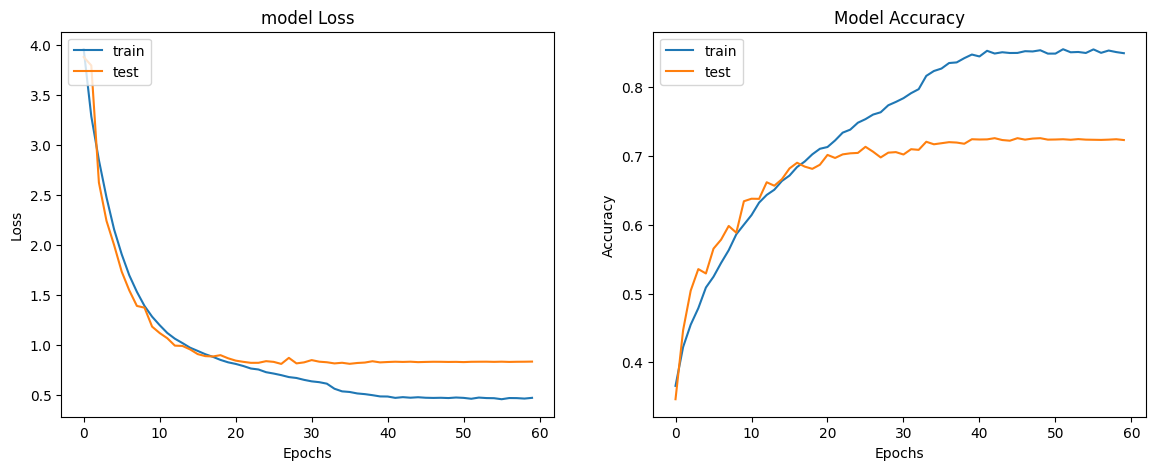

In [19]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,2)
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'test'], loc='upper left')

plt.subplot(1,2,1)
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

### Model evaluation

In [20]:
train_loss, train_accu = fernet.evaluate(training_set)
test_loss, test_accu = fernet.evaluate(test_set)
print("final train accuracy = {:.2f} , validation accuracy = {:.2f}".format(train_accu*100, test_accu*100))

82/82 [==============================] - 3s 31ms/step - loss: 0.8285 - accuracy: 0.7237
final train accuracy = 90.32 , validation accuracy = 72.37


In [21]:
fernet.save_weights('fernet_bestweight.h5')

### Confusion Matrix and Classification on training set

329/329 [==============================] - 19s 56ms/step
Confusion Matrix
[[ 761 1377  965  892]
 [1323 2554 1736 1602]
 [ 890 1655 1227 1193]
 [ 851 1706 1207 1066]]
Classification Report
              precision    recall  f1-score   support

       angry       0.20      0.19      0.19      3995
       happy       0.35      0.35      0.35      7215
     neutral       0.24      0.25      0.24      4965
         sad       0.22      0.22      0.22      4830

    accuracy                           0.27     21005
   macro avg       0.25      0.25      0.25     21005
weighted avg       0.27      0.27      0.27     21005



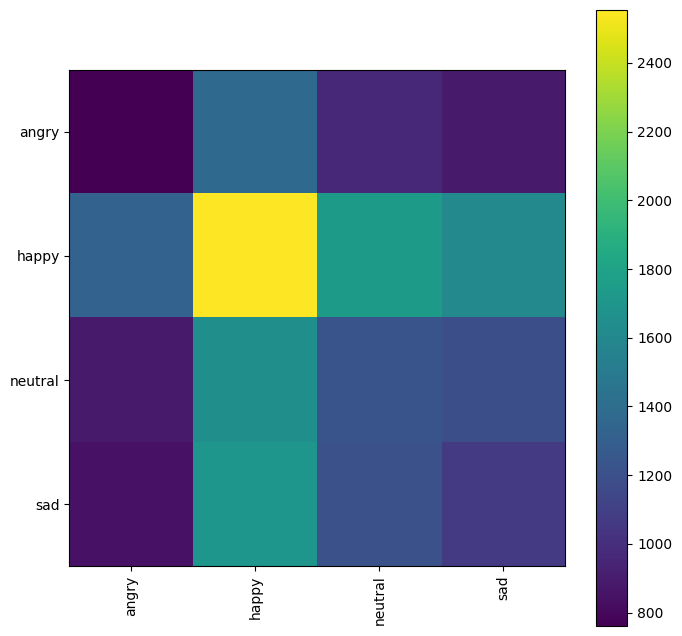

In [22]:
y_pred = fernet.predict(training_set)
y_pred = np.argmax(y_pred, axis=1)
class_labels = test_set.class_indices
class_labels = {v:k for k,v in class_labels.items()}

from sklearn.metrics import classification_report, confusion_matrix
cm_train = confusion_matrix(training_set.classes, y_pred)
print('Confusion Matrix')
print(cm_train)
print('Classification Report')
target_names = list(class_labels.values())
print(classification_report(training_set.classes, y_pred, target_names=target_names))

plt.figure(figsize=(8,8))
plt.imshow(cm_train, interpolation='nearest')
plt.colorbar()
tick_mark = np.arange(len(target_names))
_ = plt.xticks(tick_mark, target_names, rotation=90)
_ = plt.yticks(tick_mark, target_names)

### Confusion Matrix and Classification on test set

82/82 [==============================] - 2s 30ms/step
Confusion Matrix
[[159 330 237 232]
 [336 595 451 392]
 [252 439 301 241]
 [216 430 338 263]]
Classification Report
              precision    recall  f1-score   support

       angry       0.17      0.17      0.17       958
       happy       0.33      0.34      0.33      1774
     neutral       0.23      0.24      0.24      1233
         sad       0.23      0.21      0.22      1247

    accuracy                           0.25      5212
   macro avg       0.24      0.24      0.24      5212
weighted avg       0.25      0.25      0.25      5212



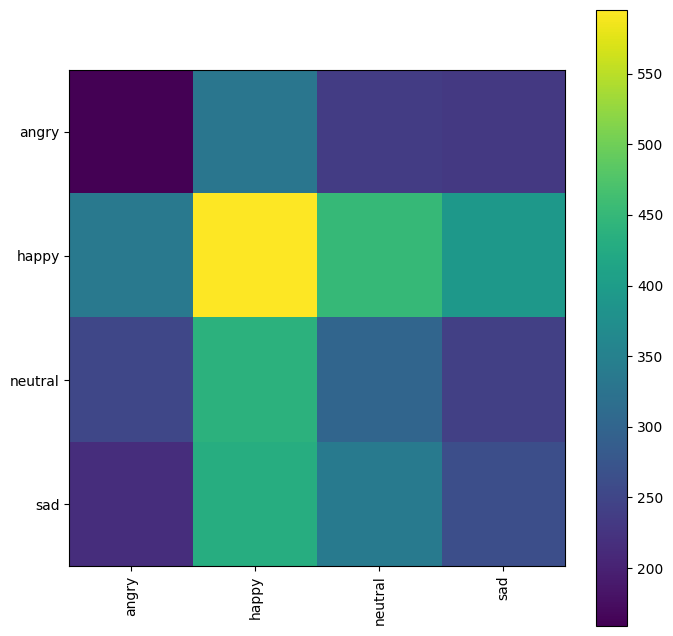

In [23]:
y_pred = fernet.predict(test_set)
y_pred = np.argmax(y_pred, axis=1)
class_labels = test_set.class_indices
class_labels = {v:k for k,v in class_labels.items()}

#from sklearn.metrics import classification_report, confusion_matrix
cm_test = confusion_matrix(test_set.classes, y_pred)
print('Confusion Matrix')
print(cm_test)
print('Classification Report')
target_names = list(class_labels.values())
print(classification_report(test_set.classes, y_pred, target_names=target_names))

plt.figure(figsize=(8,8))
plt.imshow(cm_test, interpolation='nearest')
plt.colorbar()
tick_mark = np.arange(len(target_names))
_ = plt.xticks(tick_mark, target_names, rotation=90)
_ = plt.yticks(tick_mark, target_names)